image analysis
============

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import os,time,random,kagglehub

import tensorflow as tf
from tensorflow.keras import layers, Input, models, callbacks, regularizers,initializers
from tensorflow.keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical, load_img, img_to_array
from tensorflow.keras.optimizers import Adam,AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, img_to_array
from tensorflow.keras.layers import Dense,Input,Dropout,Flatten,MaxPooling2D,Conv2D,SeparableConv2D,GlobalAveragePooling2D,GlobalMaxPooling2D,BatchNormalization

from sklearn.model_selection import train_test_split

# utility code

# -------------------------
# Reproducibility settings
# -------------------------

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

I0000 00:00:1790692506.274280    1180 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


---

## all functions given to us

In [2]:
results = {}

In [3]:
def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

In [4]:
def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

### -- wrapper train test

In [5]:
def train_and_test(model, 
                   epochs        = 500,
                   lr_schedule   = 1e-3,
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   use_early_stopping = True,
                   patience      = 10,
                   min_delta     = 0.001,
                   callbacks     = [],
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")

    # Choose optimizer
    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer

    # Compile
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    cbs = ([early_stop] if use_early_stopping else []) + callbacks

    start = time.time()

    # Fit on tf.data datasets (already batched)
    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=cbs,
        verbose=verbose
    )

    # Determine best validation accuracy
    if use_early_stopping and hasattr(early_stop, "best_epoch") and early_stop.best_epoch is not None:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = int(np.argmax(history.history['val_accuracy']))
        best_acc   = history.history['val_accuracy'][best_epoch]

    plot_learning_curves(history, title=title)

    # Evaluate on tf.data test set
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history

### -- for pulling data

In [6]:
def stratified_subsample(filepaths, labels, fraction=1.0, seed=42):
    """
    Keep the same fraction of examples from each class.
    fraction=1.0 uses the complete dataset.
    """
    if fraction >= 1.0:
        return filepaths, labels

    rng = np.random.default_rng(seed)

    keep_idx = []

    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        rng.shuffle(idx)

        n_keep = max(1, int(len(idx) * fraction))
        keep_idx.extend(idx[:n_keep])

    keep_idx = np.array(keep_idx)
    rng.shuffle(keep_idx)

    return filepaths[keep_idx], labels[keep_idx]



In [7]:
def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        # keep only classes that exist in this directory, preserve given order
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):  # deterministic within class
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names




In [8]:
def stratified_split_indices(y, val_frac=0.2, seed=42):
    """
    Deterministic stratified split over indices.
    Returns: train_idx, val_idx (np arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    # Optional: shuffle each split deterministically so batches mix classes
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx




In [9]:
def make_image_dataset(filepaths, labels, img_size=(150, 150), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk=None):
    """
    Builds a tf.data.Dataset that loads images lazily from disk.
    - filepaths: np array of strings
    - labels:    np array of int32
    """
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        # shuffle file *references* (cheap), not image tensors
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    def _load_and_preprocess(path, label):
        # read bytes -> decode -> resize -> float32 in [0,1]
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size, method="bilinear")
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_to_disk is not None:
        # Disk caching avoids RAM blowups; /tmp is fine in Colab
        ds = ds.cache(cache_to_disk)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


In [10]:
def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)


---
# pull data

- during first pull to cache.. it was 1 in 32 sec, 3.91 mbps, 346MB
- 5.8s to load if its already in cache

In [11]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

In [12]:
# --------------------------------------------------
# DATASET SIZE
#
# For faster experimentation on a slower computer,
# you may reduce DATA_FRACTION (for example, to 0.25).
#
# IMPORTANT: Set DATA_FRACTION = 1.0 and rerun the
# complete notebook before recording your final results.
# --------------------------------------------------

DATA_FRACTION = 0.15

AUTOTUNE = tf.data.AUTOTUNE


# -------------------------
# Example usage for Intel dataset
# -------------------------

IMG_SIZE      = (150, 150)
INPUT_SHAPE   = IMG_SIZE + (3,)
BATCH_SIZE    = 32
VAL_FRAC      = 0.2
SEED          = random_seed  # use your existing seed


# 1) List train files/labels deterministically
train_files, train_labels, class_names = list_files_and_labels(train_dir)

num_classes = len(class_names)

# Optional: use a smaller stratified subset while developing/debugging
train_files, train_labels = stratified_subsample(
    train_files,
    train_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

# 2) Stratified deterministic train/validation split
train_idx, val_idx = stratified_split_indices(
    train_labels,
    val_frac=VAL_FRAC,
    seed=SEED,
)

# 3) Slice file lists
files_train = train_files[train_idx]
y_train     = train_labels[train_idx]

files_val   = train_files[val_idx]
y_val       = train_labels[val_idx]

# 4) Build datasets
train_ds = make_image_dataset(
    files_train,
    y_train,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    cache_to_disk=None,
)

val_ds = make_image_dataset(
    files_val,
    y_val,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)

# 5) Test set
test_files, test_labels, _ = list_files_and_labels(
    test_dir,
    class_names=class_names,
)

# Use the same fraction for quick development runs
test_files, test_labels = stratified_subsample(
    test_files,
    test_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

test_ds = make_image_dataset(
    test_files,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)



I0000 00:00:1790692517.070277    1180 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6071 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


## -- check

In [13]:
print("class_names:", class_names)
print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

show_counts_from_labels("train", y_train, class_names)
show_counts_from_labels("val",   y_val,   class_names)
show_counts_from_labels("test",  test_labels, class_names)


class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train examples: 1683 val examples: 419 test examples: 447
train per-class counts: {'buildings': 263, 'forest': 272, 'glacier': 288, 'mountain': 301, 'sea': 273, 'street': 286}
val per-class counts: {'buildings': 65, 'forest': 68, 'glacier': 72, 'mountain': 75, 'sea': 68, 'street': 71}
test per-class counts: {'buildings': 65, 'forest': 71, 'glacier': 82, 'mountain': 78, 'sea': 76, 'street': 75}


In [14]:
# plt.figure(figsize=(12, 12))

# # Take one batch from the dataset
# images, labels = next(iter(train_ds))

# for i in range(25):
#     ax = plt.subplot(5, 5, i + 1)
#     plt.imshow(images[i].numpy())
#     plt.title(class_names[int(labels[i])], fontsize=9)
#     plt.axis("off")

# plt.tight_layout()
# plt.show()

# P0 - prelude model


Baseline Model



/home/primary-a/miniconda3/envs/tf/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790646940.457748   16650 service.cc:153] XLA service 0x73a488035410 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790646940.457790   16650 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2070 SUPER, Compute Capability 7.5 (Driver: 13.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.1)
I0000 00:00:1790646940.484644   16650 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790646940.688955   16650 cuda_dnn.cc:461] Loaded cuDNN version 92501
I0000 00:00:1790646940.737692   16650 dot_merger.cc:4

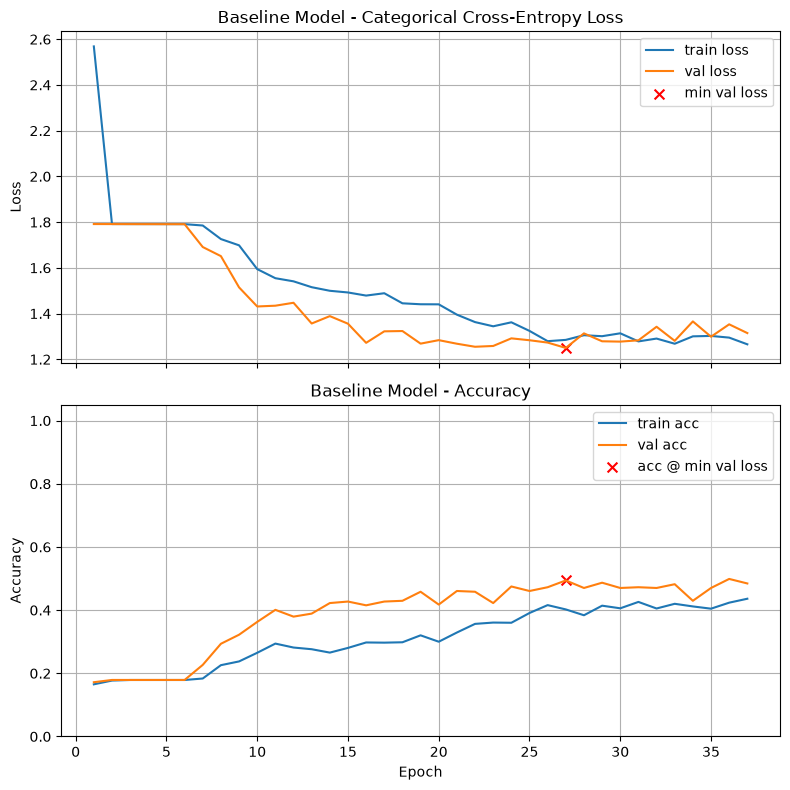

Final Training Loss:            1.2656
Final Training Accuracy:        0.4361
Final Validation Loss:          1.3147
Final Validation Accuracy:      0.4845
Minimum Validation Loss:        1.2497 (Epoch 27)
Validation Accuracy @ Min Loss: 0.4940

Test Loss: 1.1886
Test Accuracy: 0.5257

Validation-Test Gap (accuracy): 0.031694

Execution Time: 00:00:47


In [ ]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model")


--

# p1

In [ ]:
# def build_model(lr=1e-3, conv_w=64, dense_w=64, dropout=0.5, l2_reg=None):
#     reg = keras.regularizers.L2(l2_reg) if l2_reg else None
#     model = keras.Sequential([
#         layers.Conv2D(conv_w, 3, activation='relu', padding='same', input_shape=INPUT_SHAPE),
#         layers.MaxPooling2D(),
#         layers.Conv2D(conv_w * 2, 3, activation='relu', padding='same'),
#         layers.MaxPooling2D(),
#         layers.Flatten(),
#         layers.Dense(dense_w, activation='relu', kernel_regularizer=reg),
#         layers.Dropout(dropout),
#         layers.Dense(N_CLASSES, activation='softmax'),
#     ])
#     model.compile(
#         optimizer=keras.optimizers.Adam(learning_rate=lr),
#         loss='sparse_categorical_crossentropy',
#         metrics=['accuracy'],
#     )
#     return model

In [ ]:
q1_start = time.time()




baseline



/home/primary-a/miniconda3/envs/tf/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790649495.088996   16650 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14745__.31
I0000 00:00:1790649497.513035   16648 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14745__.31


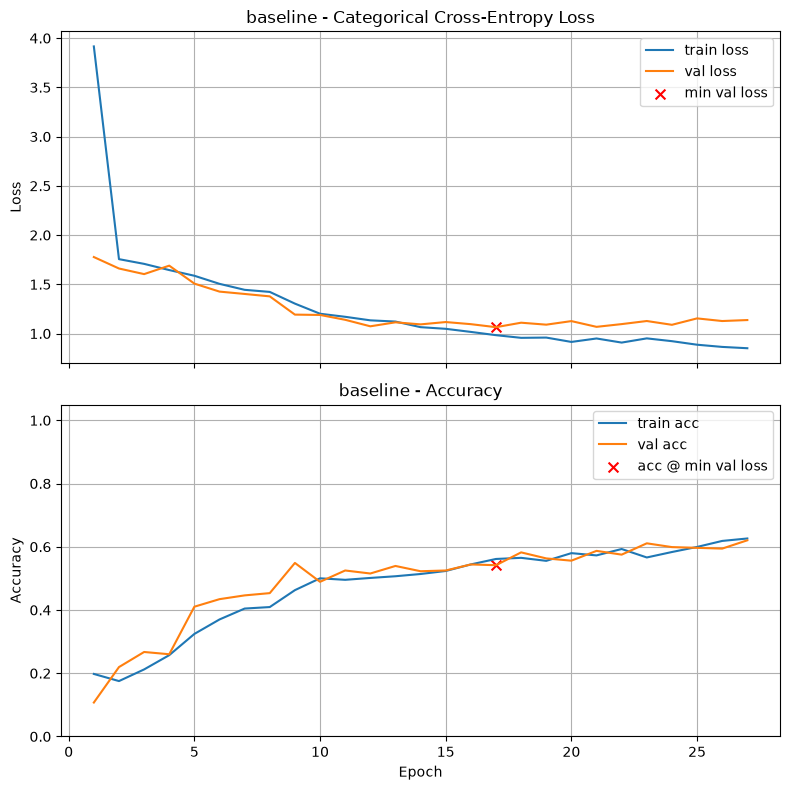

Final Training Loss:            0.8511
Final Training Accuracy:        0.6263
Final Validation Loss:          1.1372
Final Validation Accuracy:      0.6205
Minimum Validation Loss:        1.0648 (Epoch 17)
Validation Accuracy @ Min Loss: 0.5418

Test Loss: 1.0256
Test Accuracy: 0.5928

Validation-Test Gap (accuracy): 0.051075

Execution Time: 00:00:31
Problem 1 -- baseline:  val_acc = 0.620525062084198

p1--tweak2--conv[64->128]



I0000 00:00:1790649526.321379   16649 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24871__.31
E0000 00:00:1790649527.797927   16649 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1790649532.074919   16650 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_24871__.31
E0000 00:00:1790649532.478744   16650 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


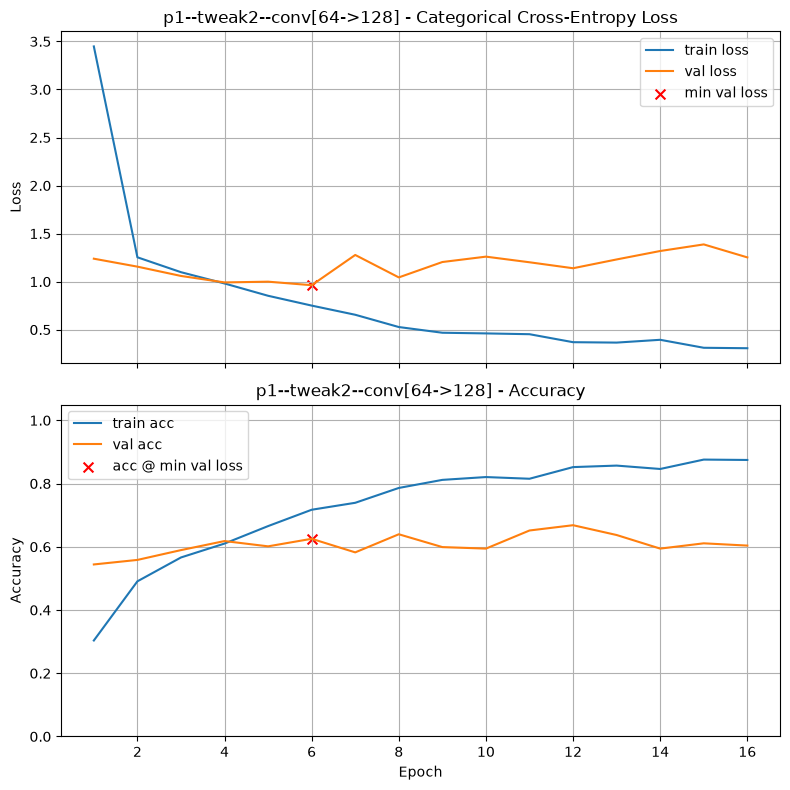

Final Training Loss:            0.3070
Final Training Accuracy:        0.8746
Final Validation Loss:          1.2525
Final Validation Accuracy:      0.6038
Minimum Validation Loss:        0.9629 (Epoch 6)
Validation Accuracy @ Min Loss: 0.6253

Test Loss: 0.9392
Test Accuracy: 0.6532

Validation-Test Gap (accuracy): 0.027946

Execution Time: 00:00:40
Problem 1 -- p1--tweak2--conv[64->128]:  val_acc = 0.6682577729225159
Overall winner: p1--tweak2--conv[64->128] with val_acc = 0.6683


In [ ]:
def baseline_model_w_options(
        dense_w=64, 
        dropout=0.5, 
        l2_reg=None, 
        layer_structure = [32, 64]
        ):
    
    he = initializers.HeNormal()       
    reg64 = regularizers.L2(l2_reg) if l2_reg else None                         

    
    layer_list = [Input(shape=INPUT_SHAPE)]
    for i in layer_structure:
        layer_list += [
            Conv2D(i, 
                   (3,3), 
                   activation="relu",    
                   kernel_initializer=he,  
                   padding="same"),
            MaxPooling2D(2),
        ]

    layer_list += [
        Flatten(),
        Dense(dense_w,          
              activation="relu",    
              kernel_initializer=he,
              kernel_regularizer=reg64),
        Dropout(dropout),
        Dense(num_classes, activation="softmax")
    ]

    model = models.Sequential(layer_list)

    return model


#### ----------------------------------------------------- ####

p1_experiment = {
    'baseline':                 dict(),
    # 'p1--tweak1--lr:0.0005':    dict(lr= 5e-4),
    'p1--tweak2--conv[64->128]':dict(layer_structure= [64,128]),
    # 'p1--tweak3--conv[64->128]':dict(layer_structure= [32,64,128]),
    # 'p1--tweak4--dense(32)':    dict(dense_w= 32),
    # 'p1--tweak5--l2_reg:1e-4':    dict(l2_reg = 1e-4),
    # 'p1--tweak6--do:0.3':    dict(dropout=0.3),

}


#### ----------------------------------------------------- ####

p1_histories = {}

for title, cfg in p1_experiment.items():
    model = baseline_model_w_options(**cfg)
    p1_histories[title] = train_and_test(
                model, 
                # epochs        = 500,
                # lr_schedule   = 1e-3,
                # optimizer     = "Adam",
                title         = title,
                # use_early_stopping = True,
                # patience      = 10,
                # min_delta     = 0.001,
                # callbacks     = [],
                # verbose       = 0,
                return_history = True
                )
    p1_acc = max(p1_histories[title].history['val_accuracy'])
    print(f'Problem 1 -- {title}:  val_acc = {p1_acc}')

p1_best_acc = max(p1_histories[title].history['val_accuracy'])
p1_best_tweak =  max(p1_histories, key=lambda t: max(p1_histories[t].history['val_accuracy']))
print(f'Overall winner: {p1_best_tweak} with val_acc = {p1_best_acc:.4f}')

In [ ]:

q1_end = time.time()

print(f"{format_hms(q1_end - q1_start)}")

00:01:11


In [ ]:
display(results)

{'Baseline Model': (0.49403342604637146, 27),
 'baseline': (0.5417661070823669, 17),
 'p1--tweak2--conv[64->128]': (0.6252983212471008, 6)}

---

# p2


p2 Model - batch normalization



/home/primary-a/miniconda3/envs/tf/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790651195.481968   16648 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32501__.41
I0000 00:00:1790651199.847338   16647 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32501__.41


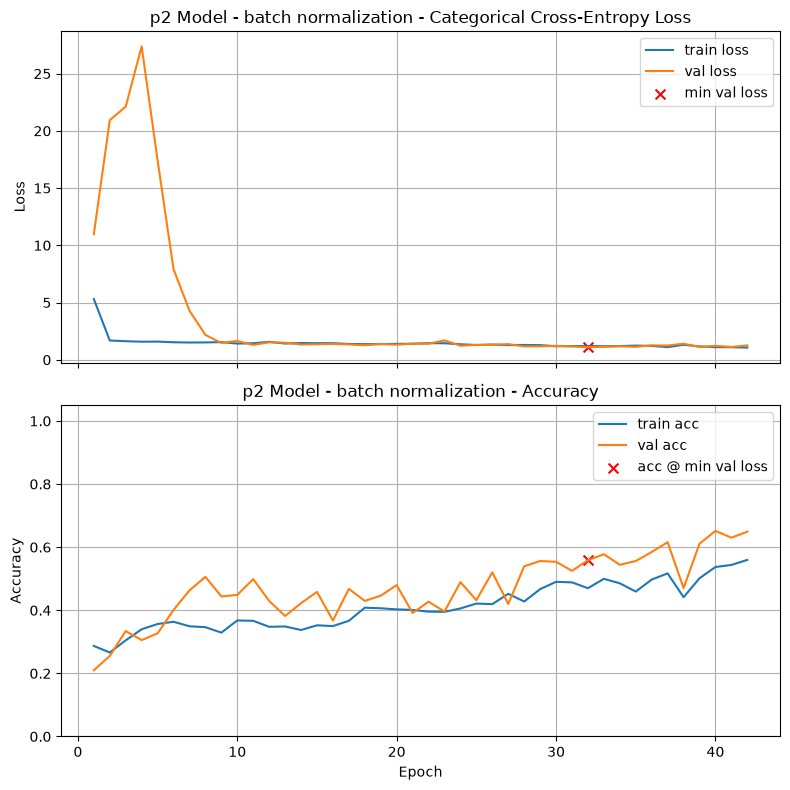

Final Training Loss:            1.0664
Final Training Accuracy:        0.5597
Final Validation Loss:          1.2527
Final Validation Accuracy:      0.6492
Minimum Validation Loss:        1.1019 (Epoch 32)
Validation Accuracy @ Min Loss: 0.5585

Test Loss: 1.1735
Test Accuracy: 0.5369

Validation-Test Gap (accuracy): 0.021560

Execution Time: 00:00:54


In [ ]:
he = initializers.HeNormal()                                # best initializer for relu

p2_model= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(p2_model,title=f"p2 Model - batch normalization")

---
# p3


p3-baseline



/home/primary-a/miniconda3/envs/tf/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790651651.353306   16648 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_47323__.31
I0000 00:00:1790651653.837640   16645 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_47323__.31


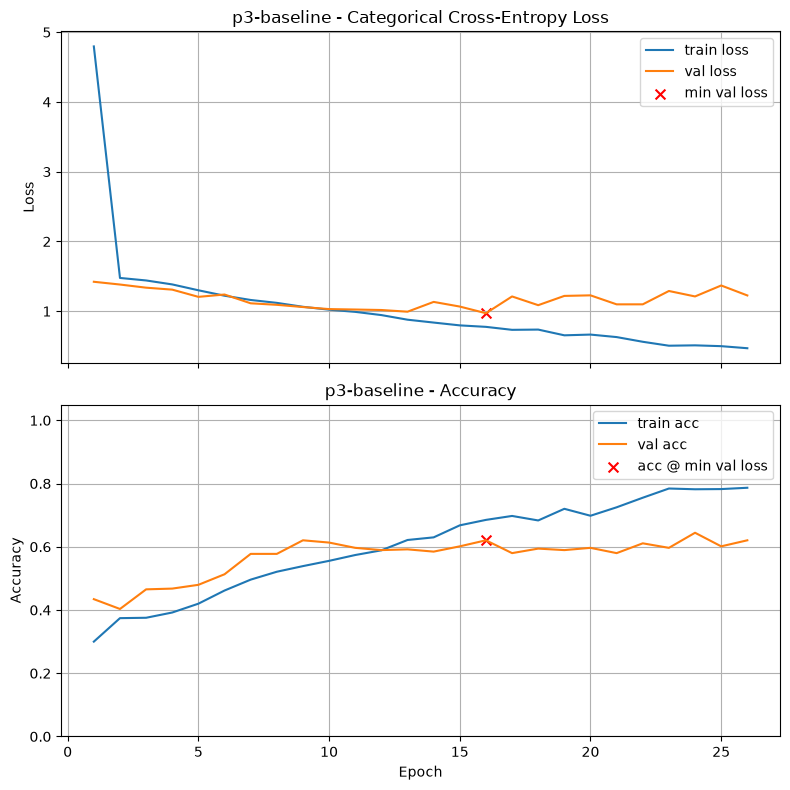

Final Training Loss:            0.4692
Final Training Accuracy:        0.7867
Final Validation Loss:          1.2260
Final Validation Accuracy:      0.6205
Minimum Validation Loss:        0.9711 (Epoch 16)
Validation Accuracy @ Min Loss: 0.6205

Test Loss: 0.9653
Test Accuracy: 0.6309

Validation-Test Gap (accuracy): 0.010347

Execution Time: 00:00:30
Problem 1 -- p3-baseline:  val_acc = 0.6443914175033569

p3--tweak2--conv[64->128]



I0000 00:00:1790651681.663035   16647 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_57169__.31
I0000 00:00:1790651684.797035   16649 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_57169__.31


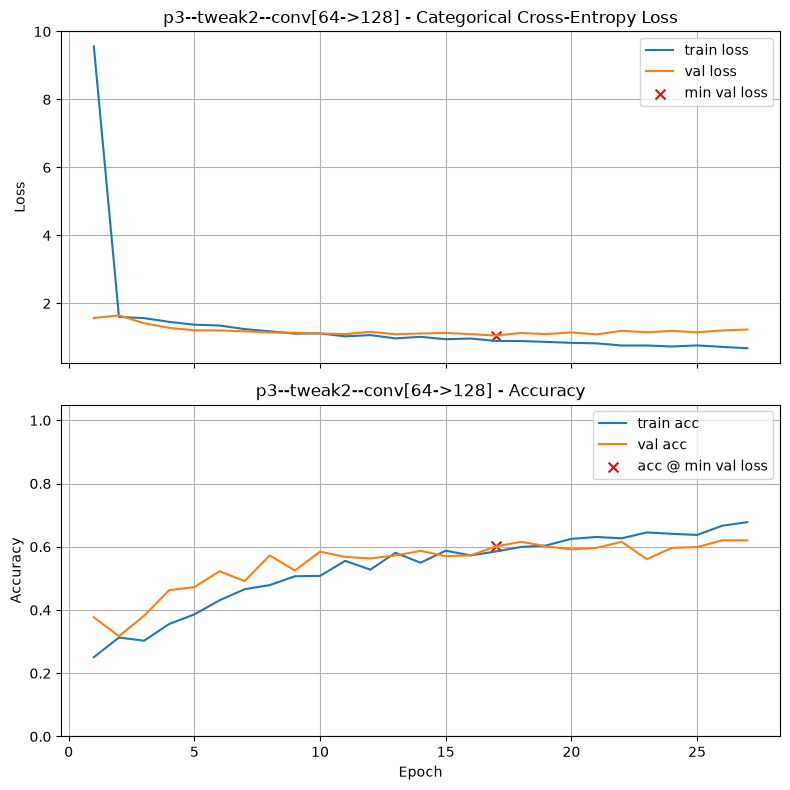

Final Training Loss:            0.6795
Final Training Accuracy:        0.6780
Final Validation Loss:          1.2304
Final Validation Accuracy:      0.6205
Minimum Validation Loss:        1.0522 (Epoch 17)
Validation Accuracy @ Min Loss: 0.6014

Test Loss: 0.9991
Test Accuracy: 0.6331

Validation-Test Gap (accuracy): 0.031678

Execution Time: 00:00:52
Problem 1 -- p3--tweak2--conv[64->128]:  val_acc = 0.620525062084198
Overall winner: p3-baseline with val_acc = 0.6205


In [ ]:
def p3_model(
        # dense_w=64, 
        # dropout=0.5, 
        # l2_reg=None, 
        layer_structure = [32, 64]
        ):
    
    # he = initializers.HeNormal()       
    # reg64 = regularizers.L2(l2_reg) if l2_reg else None                         

    
    layer_list = [Input(shape=INPUT_SHAPE)]
    for i in layer_structure:
        layer_list += [
            Conv2D(i, 
                   (3,3), 
                   activation="relu",    
                   kernel_initializer=he,  
                   padding="same"),
            MaxPooling2D(2),
        ]

    layer_list += [
        # Flatten(),
        # Dense(dense_w,          
        #       activation="relu",    
        #       kernel_initializer=he,
        #       kernel_regularizer=reg64),
        # Dropout(dropout),
        GlobalAveragePooling2D(),
        Dense(num_classes, activation="softmax")
    ]

    model = models.Sequential(layer_list)

    return model


#### ----------------------------------------------------- ####

p3_experiment = {
    'p3-baseline':                 dict(),
    # 'p1--tweak1--lr:0.0005':    dict(lr= 5e-4),
    'p3--tweak2--conv[64->128]':dict(layer_structure= [64,128]),
    # 'p1--tweak3--conv[64->128]':dict(layer_structure= [32,64,128]),
    # 'p1--tweak4--dense(32)':    dict(dense_w= 32),
    # 'p1--tweak5--l2_reg:1e-4':    dict(l2_reg = 1e-4),
    # 'p1--tweak6--do:0.3':    dict(dropout=0.3),

}


#### ----------------------------------------------------- ####

p3_histories = {}

for title, cfg in p3_experiment.items():
    model = baseline_model_w_options(**cfg)
    p3_histories[title] = train_and_test(
                model, 
                # epochs        = 500,
                # lr_schedule   = 1e-3,
                # optimizer     = "Adam",
                title         = title,
                # use_early_stopping = True,
                # patience      = 10,
                # min_delta     = 0.001,
                # callbacks     = [],
                # verbose       = 0,
                return_history = True
                )
    p3_acc = max(p3_histories[title].history['val_accuracy'])
    print(f'Problem 1 -- {title}:  val_acc = {p3_acc}')

p3_best_acc = max(p3_histories[title].history['val_accuracy'])
p3_best_tweak =  max(p3_histories, key=lambda t: max(p3_histories[t].history['val_accuracy']))
print(f'Overall winner: {p3_best_tweak} with val_acc = {p3_best_acc:.4f}')

In [ ]:
display(results)

{'Baseline Model': (0.49403342604637146, 27),
 'baseline': (0.5417661070823669, 17),
 'p1--tweak2--conv[64->128]': (0.6252983212471008, 6),
 'p2 Model - batch normalization': (0.5584725737571716, 32),
 'p3-baseline': (0.620525062084198, 16),
 'p3--tweak2--conv[64->128]': (0.6014319658279419, 17)}

---

# p4


factor: 0.5



/home/primary-a/miniconda3/envs/tf/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790653434.132400   16648 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_66936__.30
I0000 00:00:1790653436.298168   16645 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_66936__.30


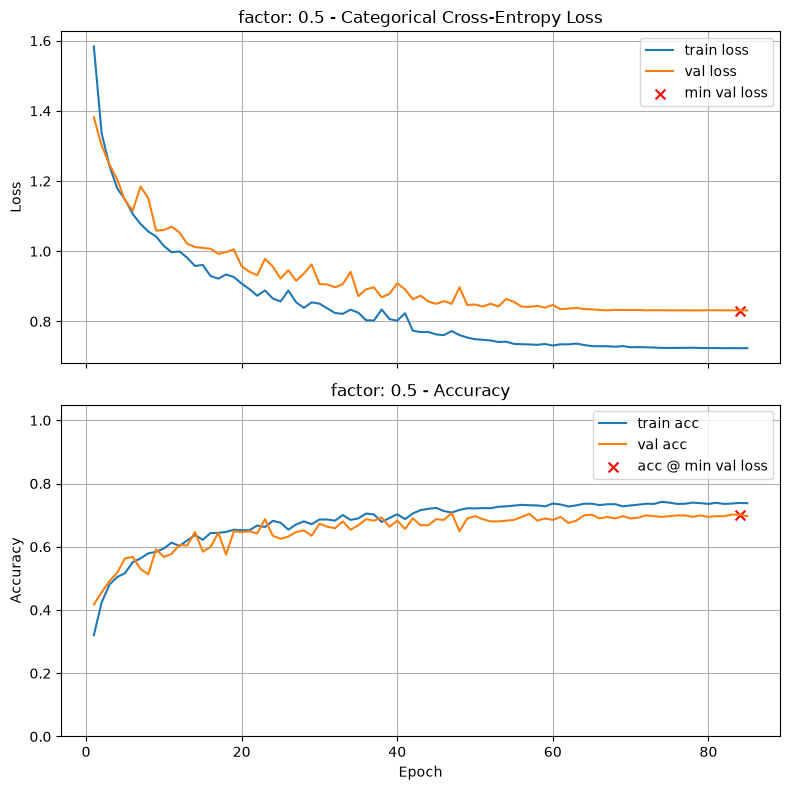

Final Training Loss:            0.7237
Final Training Accuracy:        0.7380
Final Validation Loss:          0.8313
Final Validation Accuracy:      0.6969
Minimum Validation Loss:        0.8311 (Epoch 84)
Validation Accuracy @ Min Loss: 0.7017

Test Loss: 0.8170
Test Accuracy: 0.7002

Validation-Test Gap (accuracy): 0.003326

Execution Time: 00:01:27

factor: 0.3



I0000 00:00:1790653522.005864   16649 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_94481__.30
I0000 00:00:1790653523.970339   16649 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_94481__.30


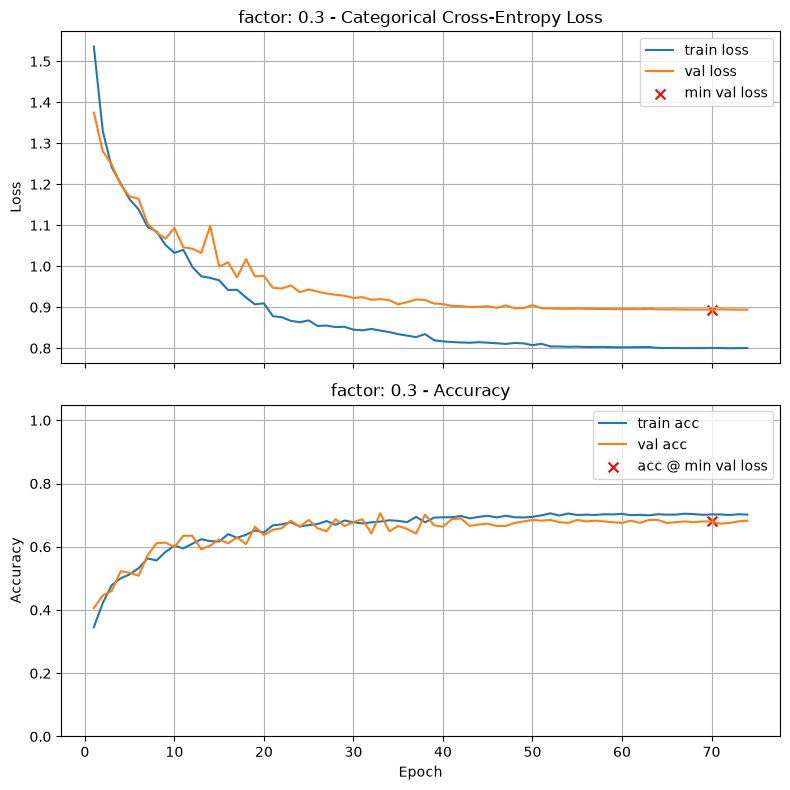

Final Training Loss:            0.8003
Final Training Accuracy:        0.7017
Final Validation Loss:          0.8941
Final Validation Accuracy:      0.6826
Minimum Validation Loss:        0.8941 (Epoch 70)
Validation Accuracy @ Min Loss: 0.6802

Test Loss: 0.8836
Test Accuracy: 0.6510

Validation-Test Gap (accuracy): 0.033957

Execution Time: 00:01:10

factor: 0.2



I0000 00:00:1790653592.546664   16650 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_118662__.30
I0000 00:00:1790653594.477799   16648 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_118662__.30


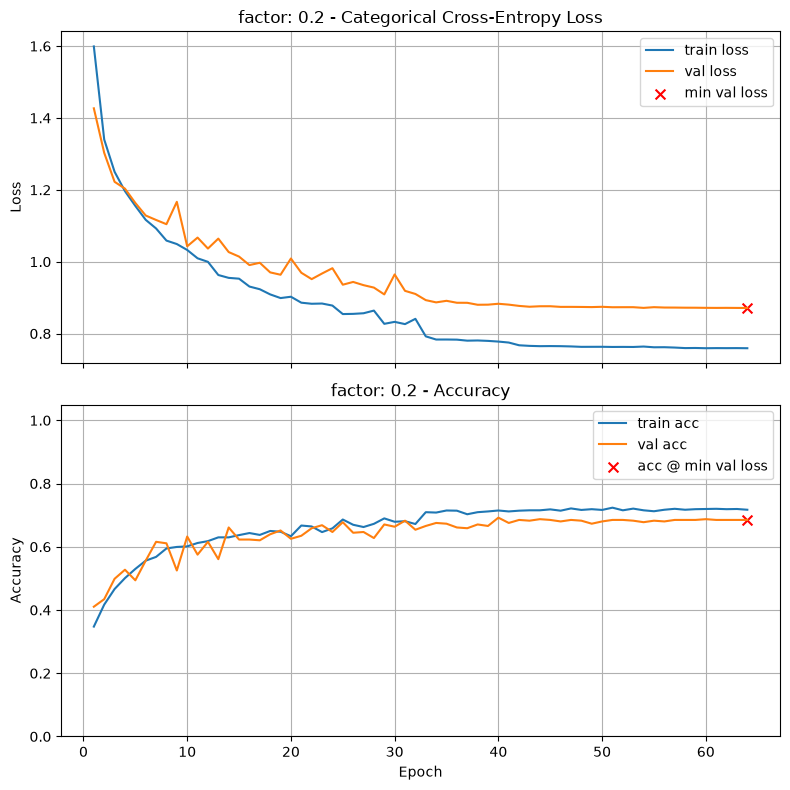

Final Training Loss:            0.7593
Final Training Accuracy:        0.7172
Final Validation Loss:          0.8712
Final Validation Accuracy:      0.6850
Minimum Validation Loss:        0.8712 (Epoch 64)
Validation Accuracy @ Min Loss: 0.6850

Test Loss: 0.8511
Test Accuracy: 0.6756

Validation-Test Gap (accuracy): 0.002189

Execution Time: 00:01:01

patience: 3



I0000 00:00:1790653654.032644   16650 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_139820__.30
I0000 00:00:1790653656.002080   16650 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_139820__.30


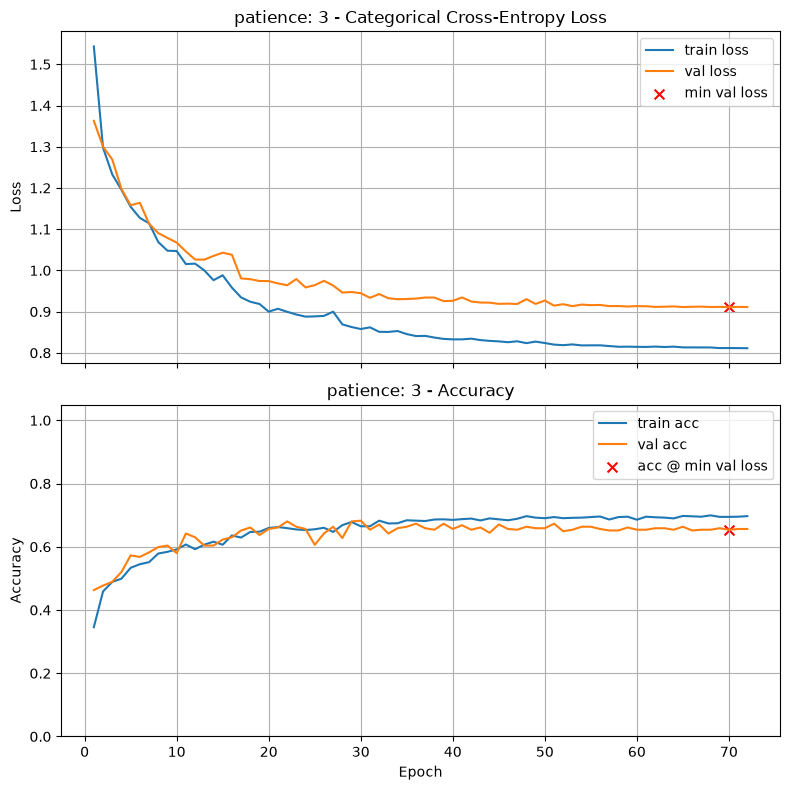

Final Training Loss:            0.8112
Final Training Accuracy:        0.6970
Final Validation Loss:          0.9111
Final Validation Accuracy:      0.6563
Minimum Validation Loss:        0.9109 (Epoch 70)
Validation Accuracy @ Min Loss: 0.6539

Test Loss: 0.8973
Test Accuracy: 0.6555

Validation-Test Gap (accuracy): 0.003230

Execution Time: 00:01:08

patience: 5



I0000 00:00:1790653722.906104   16649 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_163389__.30
I0000 00:00:1790653724.859764   16648 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_163389__.30


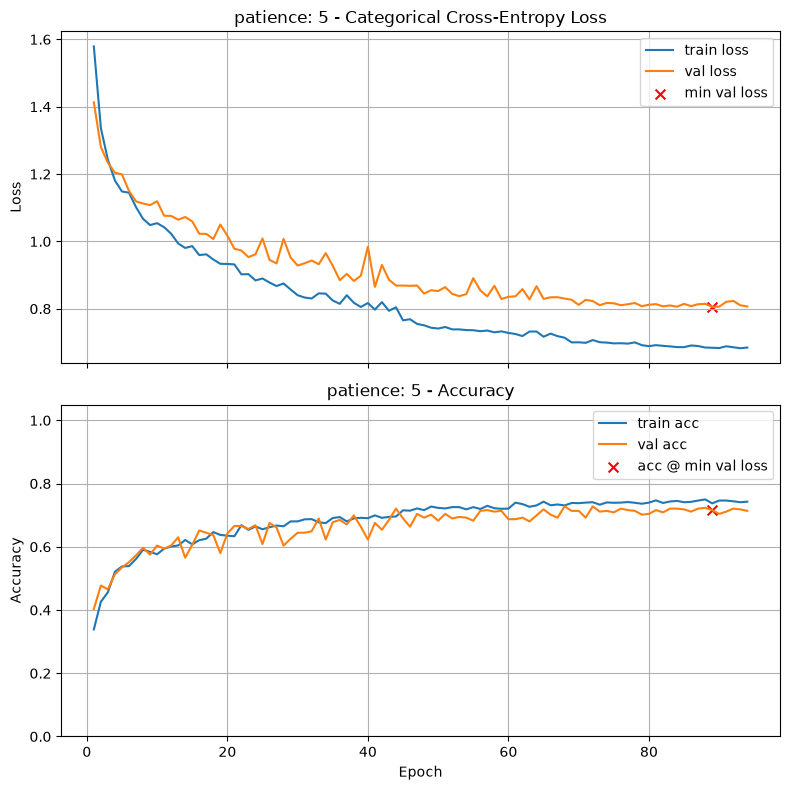

Final Training Loss:            0.6849
Final Training Accuracy:        0.7427
Final Validation Loss:          0.8067
Final Validation Accuracy:      0.7136
Minimum Validation Loss:        0.8057 (Epoch 89)
Validation Accuracy @ Min Loss: 0.7160

Test Loss: 0.7771
Test Accuracy: 0.7114

Validation-Test Gap (accuracy): 0.009354

Execution Time: 00:01:28


In [ ]:
def reduce_lr(factor=0.5, patience=3, min_delta=1e-4):
    return ReduceLROnPlateau(
        monitor='val_loss',
        factor=factor,
        patience=patience,
        cooldown=1,
        min_delta=min_delta,
        min_lr=1e-5,
        verbose=0,
    )


factor_runs = {
    f'p4-factor: {f}': dict(factor=f)
    for f in [0.5, 0.3, 0.2]
}

patience_runs = {
    f'p4-patience: {p}': dict(patience=p)
    for p in [3, 5]
}

p4_record = []
for tweak, run in ('factor', factor_runs), ('patience', patience_runs):
    for title, cfg in run.items():
        p4_history = train_and_test(
            p3_model(),
            callbacks=[reduce_lr(**cfg)],
            title=title,
            return_history=True,
        )

        p4_acc = max(p4_history.history["val_accuracy"])
        p4_record.append({
            'config': tweak,
            'setting': title,
            'val_acc': p4_acc
        })




In [ ]:
# p4_results = (
#     pd.DataFrame(p4_record)
#     .sort_values('val_acc', ascending = False)
# )

In [ ]:
results

{'Baseline Model': (0.49403342604637146, 27),
 'baseline': (0.5417661070823669, 17),
 'p1--tweak2--conv[64->128]': (0.6252983212471008, 6),
 'p2 Model - batch normalization': (0.5584725737571716, 32),
 'p3-baseline': (0.620525062084198, 16),
 'p3--tweak2--conv[64->128]': (0.6014319658279419, 17),
 'factor: 0.5': (0.7016706466674805, 84),
 'factor: 0.3': (0.680190920829773, 70),
 'factor: 0.2': (0.6849641799926758, 64),
 'patience: 3': (0.6539379358291626, 70),
 'patience: 5': (0.715990424156189, 89)}

---

# p5 


VGG-style Large



/home/primary-a/miniconda3/envs/tf/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790692545.790748    4280 service.cc:153] XLA service 0x7c03cc03add0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790692545.790790    4280 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2070 SUPER, Compute Capability 7.5 (Driver: 13.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.1)
I0000 00:00:1790692545.863988    4280 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790692546.452371    4280 cuda_dnn.cc:461] Loaded cuDNN version 92501
I0000 00:00:1790692546.527602    4280 dot_merger.cc:4

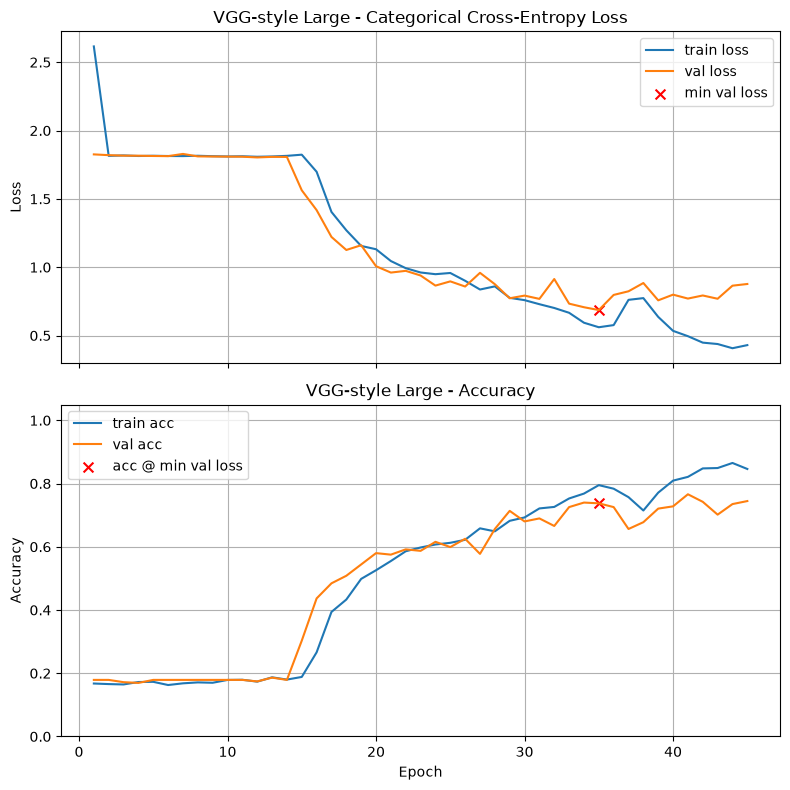

Final Training Loss:            0.4298
Final Training Accuracy:        0.8461
Final Validation Loss:          0.8771
Final Validation Accuracy:      0.7446
Minimum Validation Loss:        0.6864 (Epoch 35)
Validation Accuracy @ Min Loss: 0.7375

Test Loss: 0.7066
Test Accuracy: 0.7204

Validation-Test Gap (accuracy): 0.017112

Execution Time: 00:05:53


In [16]:
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value

model_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3×3×512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    # Global pooling meaningfully summarizes the 3×3 map
    layers.GlobalAveragePooling2D(),   # swap to GlobalMaxPooling2D() to compare

    # Compact head
    layers.Dense(256, activation='relu', kernel_initializer=he,
                 kernel_regularizer=l2reg),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Uncomment the next line to run

train_and_test(model_vgg_16,lr_schedule=1e-3,title="VGG-style Large")


In [ ]:
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value

model2_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3×3×512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    # Global pooling meaningfully summarizes the 3×3 map
    layers.GlobalAveragePooling2D(),   # swap to GlobalMaxPooling2D() to compare

    # Compact head
    layers.Dense(256, activation='relu', kernel_initializer=he,
                 kernel_regularizer=l2reg),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Uncomment the next line to run

train_and_test(model2_vgg_16,lr_schedule=3e-3,title="VGG-style Large 3e-3")



VGG-style Large 3e-3



/home/primary-a/miniconda3/envs/tf/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790694791.143797    4280 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23522__.50
I0000 00:00:1790694800.872637    4281 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23522__.50
